# 02 Resampling and Transition Bank

This notebook continues with the same real trajectories and turns them into fixed-arc-length prediction objects. The emphasis is on verifying that the real data still look coherent after resampling and that transition windows respect gap boundaries.


## Goals

1. Smooth a small real-data subset.
2. Resample onto a shared arc-length grid.
3. Inspect transition windows and bank density.
4. Check that gap annotations and segment boundaries survive into the bank.


In [10]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "dev" / "particle_prediction" / "data" / "loading.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dev.particle_prediction.data.loading import DEFAULT_BUILD_DIR, FILE_PREFIX, load_trajectories
from dev.particle_prediction.data.smoothing import smooth_trajectory, smooth_trajectories
from dev.particle_prediction.data.resampling import compute_cumulative_arc_length, resample_smoothed_trajectory, resample_smoothed_trajectories
from dev.particle_prediction.data.transition_windows import build_transition_windows
from dev.particle_prediction.data.transition_bank import build_transition_bank
from dev.particle_prediction.data.dataset import build_prediction_tasks, build_query_from_resampled_trajectory
from dev.particle_prediction.eval.evaluate import comparison_table, run_evaluation_suite
from dev.particle_prediction.models.local_transition_pf import LocalTransitionPredictor
from dev.particle_prediction.models.matching import MatchingConfig, compare_matching_modes
from dev.particle_prediction.viz.smoothing import (
    plot_latent_trajectory_before_after_smoothing,
    plot_raw_vs_smoothed_timeseries,
    plot_sg_parameter_sweep,
)
from dev.particle_prediction.viz.transition_bank import (
    plot_arc_length_vs_time,
    plot_bank_state_density,
    plot_history_segments_example,
    plot_increment_norm_distribution,
    plot_resampled_points_on_trajectory,
    plot_transition_windows_for_embryo,
)
from dev.particle_prediction.viz.matching import (
    compare_default_vs_fast_matching,
    plot_history_offset_heatmap,
    plot_history_reranking,
    plot_query_and_candidate_neighbors,
)
from dev.particle_prediction.viz.prediction import (
    plot_local_increment_cloud,
    plot_prediction_fan,
    plot_rollout_against_truth,
    plot_sampled_next_steps,
    plot_support_diagnostics_along_rollout,
)
from dev.particle_prediction.viz.evaluation import (
    plot_error_vs_horizon,
    plot_error_vs_support,
    plot_failure_gallery,
    plot_model_comparison_table,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

def resolve_real_data_context(max_default_trajectories=8):
    build_dir = Path(os.environ.get("MORPHSEQ_PARTICLE_BUILD_DIR", project_root / DEFAULT_BUILD_DIR))
    if not build_dir.exists():
        raise FileNotFoundError(
            f"Expected real data under {build_dir}. Set MORPHSEQ_PARTICLE_BUILD_DIR to override."
        )

    available_experiments = sorted(
        path.stem[len(FILE_PREFIX):]
        for path in build_dir.glob(f"{FILE_PREFIX}*.csv")
    )
    if not available_experiments:
        raise FileNotFoundError(f"No {FILE_PREFIX}*.csv files found in {build_dir}")

    env_experiments = os.environ.get("MORPHSEQ_PARTICLE_EXPERIMENTS")
    experiment_ids = [part.strip() for part in env_experiments.split(",") if part.strip()] if env_experiments else [available_experiments[0]]
    env_limit = os.environ.get("MORPHSEQ_PARTICLE_MAX_TRAJECTORIES")
    max_trajectories = int(env_limit) if env_limit else max_default_trajectories
    return build_dir, available_experiments, experiment_ids, max_trajectories

build_dir, available_experiments, experiment_ids, max_trajectories = resolve_real_data_context()
print(f"Project root: {project_root}")
print(f"Build dir: {build_dir}")
print(f"Available experiments: {available_experiments[:5]}{' ...' if len(available_experiments) > 5 else ''}")
print(f"Notebook experiments: {experiment_ids}")
print(f"Trajectory cap: {max_trajectories}")


Project root: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq
Build dir: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/morphseq_playground/metadata/build06_output
Available experiments: ['20230525', '20230531', '20230613', '20230615', '20230622'] ...
Notebook experiments: ['20230525']
Trajectory cap: 8


In [2]:
dataset = load_trajectories(
    build_dir=build_dir,
    experiment_ids=experiment_ids,
    n_components=10,
    scale=True,
    min_trajectory_length=5,
    verbose=False,
)
selected_trajectories = dataset.trajectories[:max_trajectories]
summary_df = pd.DataFrame(
    {
        "embryo_id": [traj.embryo_id for traj in selected_trajectories],
        "experiment_id": [traj.experiment_id for traj in selected_trajectories],
        "perturbation_class": [traj.perturbation_class for traj in selected_trajectories],
        "n_frames": [len(traj.time_seconds) for traj in selected_trajectories],
        "delta_t": [traj.delta_t for traj in selected_trajectories],
        "n_hard_gaps": [int(np.sum(traj.hard_gap_mask)) if traj.hard_gap_mask is not None else 0 for traj in selected_trajectories],
        "n_interpolatable_gaps": [int(np.sum(traj.interpolatable_gap_mask)) if traj.interpolatable_gap_mask is not None else 0 for traj in selected_trajectories],
    }
)
print(f"Loaded {len(dataset.trajectories)} trajectories; using first {len(selected_trajectories)} for the notebook walkthrough.")
summary_df.head(10)


Loaded 65 trajectories; using first 8 for the notebook walkthrough.


,embryo_id,experiment_id,perturbation_class,n_frames,delta_t,n_hard_gaps,n_interpolatable_gaps
0,20230525_A03_e01,20230525,wik,61,3000.3508,0,0
1,20230525_A04_e02,20230525,wik,5,3000.3508,0,0
2,20230525_A05_e01,20230525,wik,18,3000.3508,0,0
3,20230525_A06_e01,20230525,wik,17,3000.3508,0,0
4,20230525_A07_e01,20230525,wik,32,3000.3508,0,0
5,20230525_A09_e01,20230525,wik,58,3000.3508,0,2
6,20230525_A11_e01,20230525,wik,60,3000.3508,0,0
7,20230525_A12_e01,20230525,wik,59,3000.3508,0,1


In [4]:
window_seconds = 7.0 * 3600.0
poly_order = 2
delta_s = 0.25
smoothed_subset = smooth_trajectories(selected_trajectories, window_seconds=window_seconds, poly_order=poly_order)
resampled_subset = resample_smoothed_trajectories(smoothed_subset, delta_s=delta_s)
resampled_summary = pd.DataFrame(
    {
        "embryo_id": [traj.source.embryo_id for traj in resampled_subset],
        "n_raw": [len(traj.source.time_seconds) for traj in resampled_subset],
        "n_resampled": [len(traj.arc_length) for traj in resampled_subset],
        "total_arc_length": [traj.arc_length[-1] for traj in resampled_subset],
        "delta_s": [traj.delta_s for traj in resampled_subset],
    }
)
resampled_summary.head(10)


,embryo_id,n_raw,n_resampled,total_arc_length,delta_s
0,20230525_A03_e01,61,292,72.6200,0.25
1,20230525_A04_e02,5,18,4.0269,0.25
2,20230525_A05_e01,18,122,30.0821,0.25
3,20230525_A06_e01,17,124,30.5703,0.25
4,20230525_A07_e01,32,184,45.6628,0.25
5,20230525_A09_e01,58,262,65.1988,0.25
6,20230525_A11_e01,60,235,58.3535,0.25
7,20230525_A12_e01,59,320,79.6954,0.25


## Resampling QC

Inspect one real embryo in detail before building the bank.


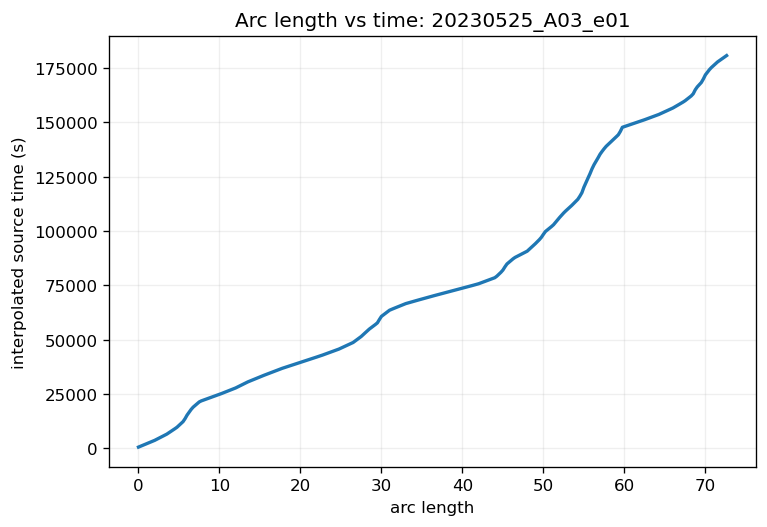

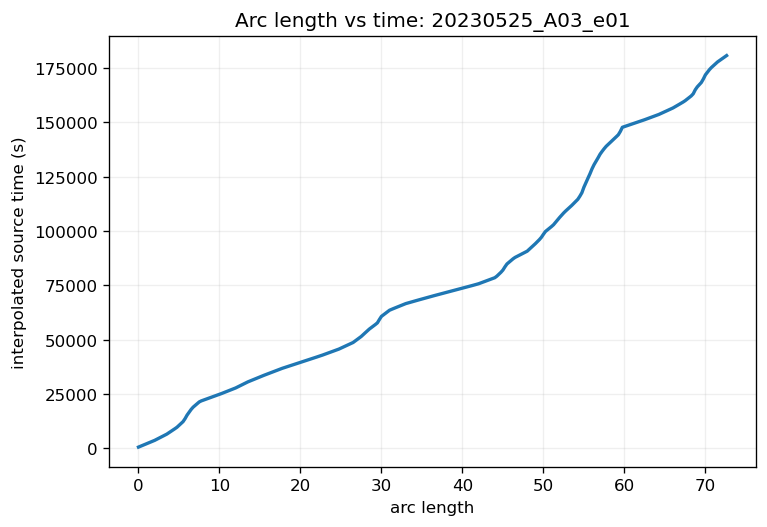

In [5]:
resampled_example = resampled_subset[0]
plot_arc_length_vs_time(resampled_example)


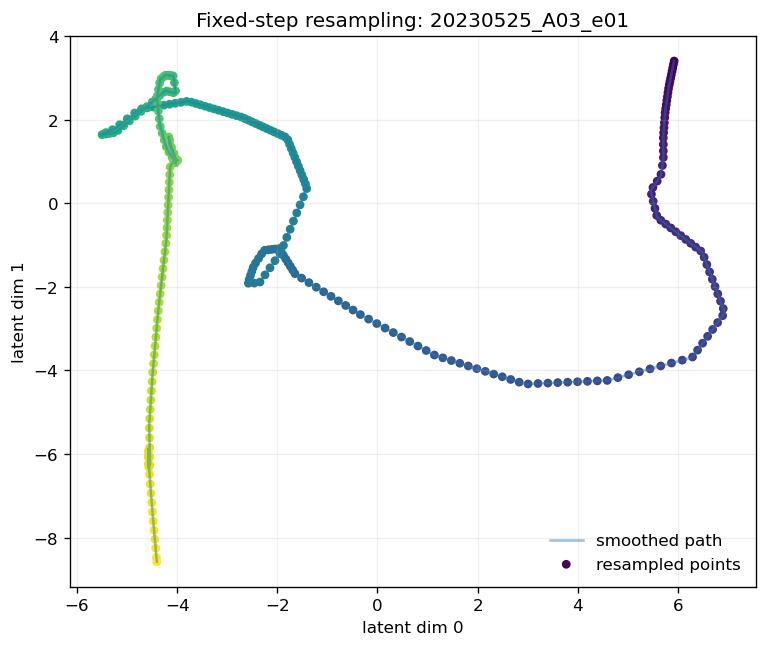

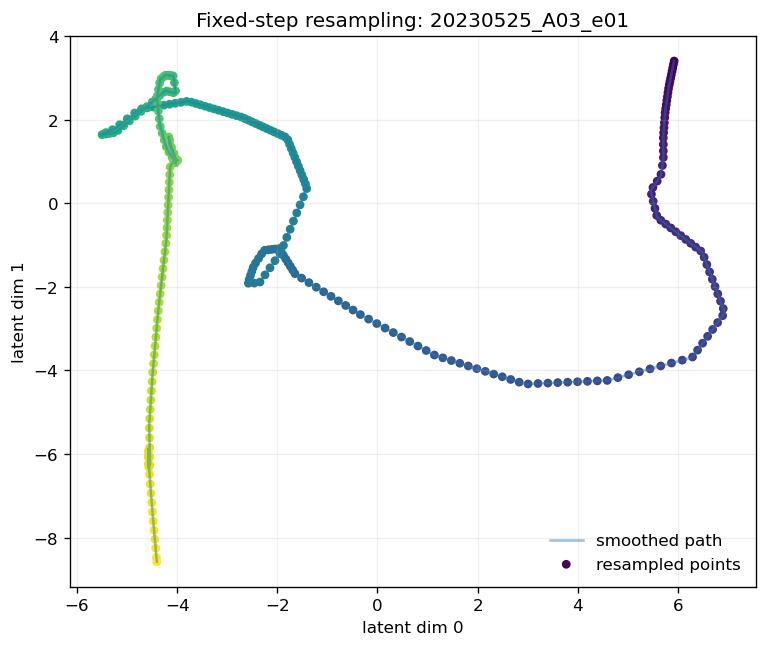

In [6]:
plot_resampled_points_on_trajectory(resampled_example)


In [ ]:
plot_increment_norm_distribution(resampled_subset)


## Transition Windows

Build windows on one embryo first so the canonical history object stays interpretable.


In [7]:
history_length = 5
windows = build_transition_windows(resampled_example, history_length=history_length)
print(f"Built {len(windows)} windows for {resampled_example.source.embryo_id}")
pd.DataFrame(
    {
        "resampled_index": [window.resampled_index for window in windows[:10]],
        "segment_id": [window.source_segment_id for window in windows[:10]],
        "touches_interpolated_gap": [window.touches_interpolated_gap for window in windows[:10]],
        "arc_length_value": [window.arc_length_value for window in windows[:10]],
    }
)


Built 286 windows for 20230525_A03_e01


,resampled_index,segment_id,touches_interpolated_gap,arc_length_value
0,5,0,False,1.25
1,6,0,False,1.50
2,7,0,False,1.75
3,8,0,False,2.00
4,9,0,False,2.25
5,10,0,False,2.50
6,11,0,False,2.75
7,12,0,False,3.00
8,13,0,False,3.25
9,14,0,False,3.50


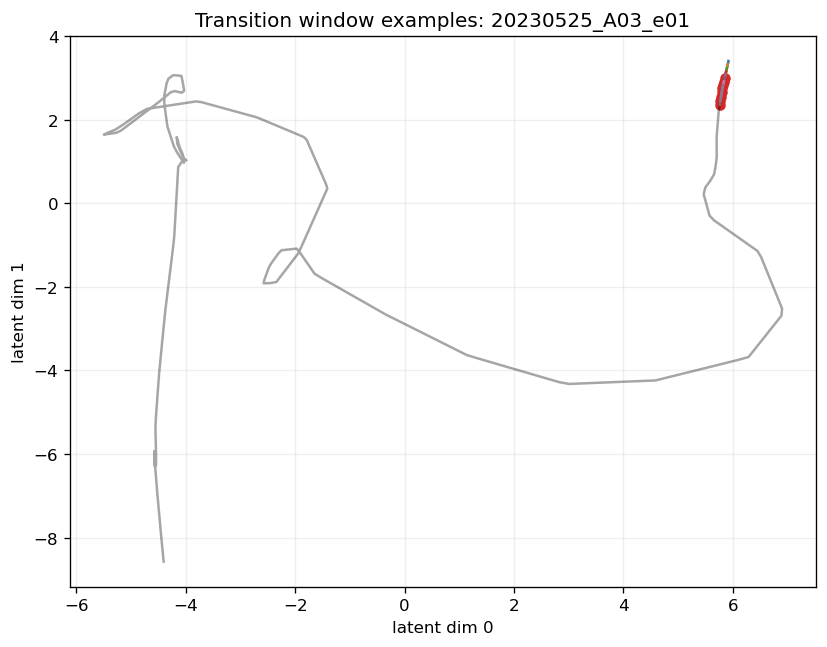

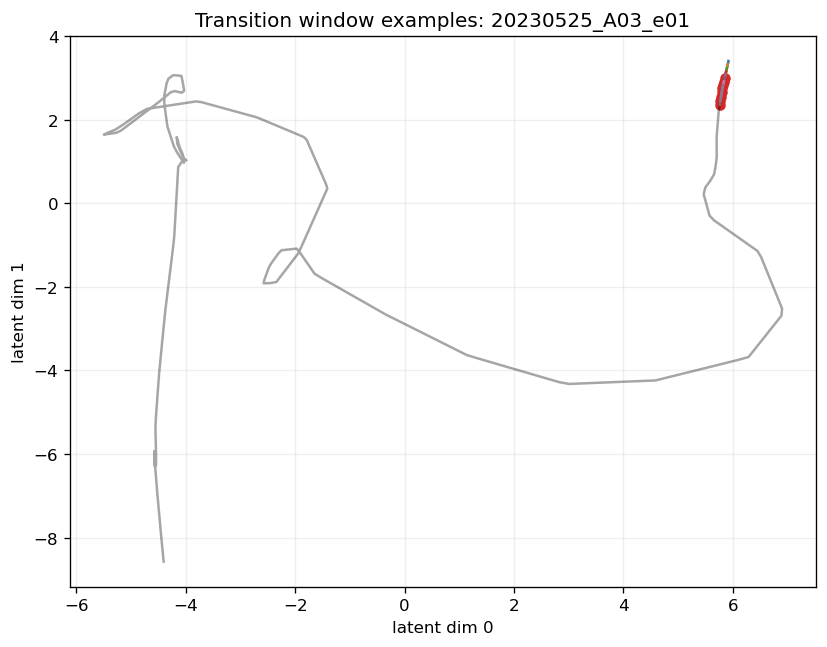

In [8]:
plot_transition_windows_for_embryo(resampled_example, windows[: min(len(windows), 80)])


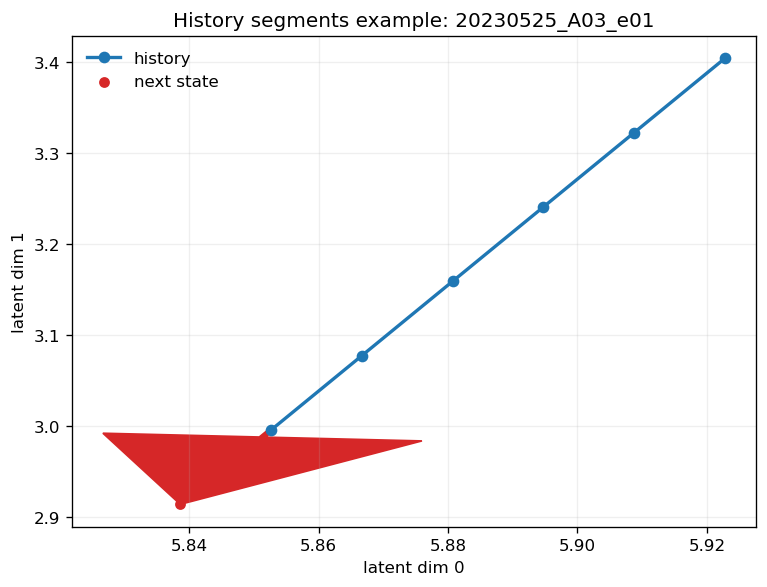

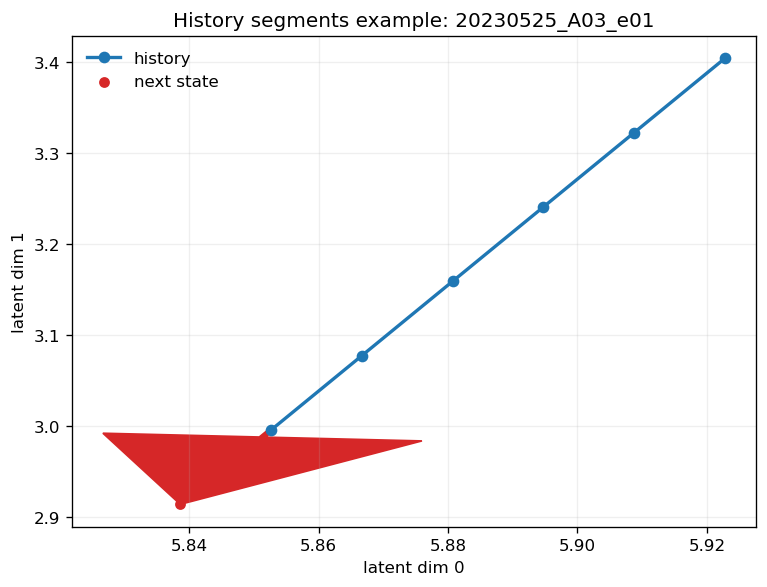

In [11]:
plot_history_segments_example(windows[0])


## Transition Bank

Now build the bank across the notebook subset and inspect density plus propagated gap flags.


In [12]:
bank = build_transition_bank(resampled_subset, history_length=history_length, use_state_index=True)
print(f"Bank windows: {len(bank)}")
pd.DataFrame(
    {
        "embryo_id": bank.embryo_ids[:10],
        "segment_id": bank.segment_ids[:10],
        "touches_interpolated_gap": bank.touches_interpolated_gap[:10],
    }
)


Bank windows: 1509


,embryo_id,segment_id,touches_interpolated_gap
0,20230525_A03_e01,0,False
1,20230525_A03_e01,0,False
2,20230525_A03_e01,0,False
3,20230525_A03_e01,0,False
4,20230525_A03_e01,0,False
5,20230525_A03_e01,0,False
6,20230525_A03_e01,0,False
7,20230525_A03_e01,0,False
8,20230525_A03_e01,0,False
9,20230525_A03_e01,0,False


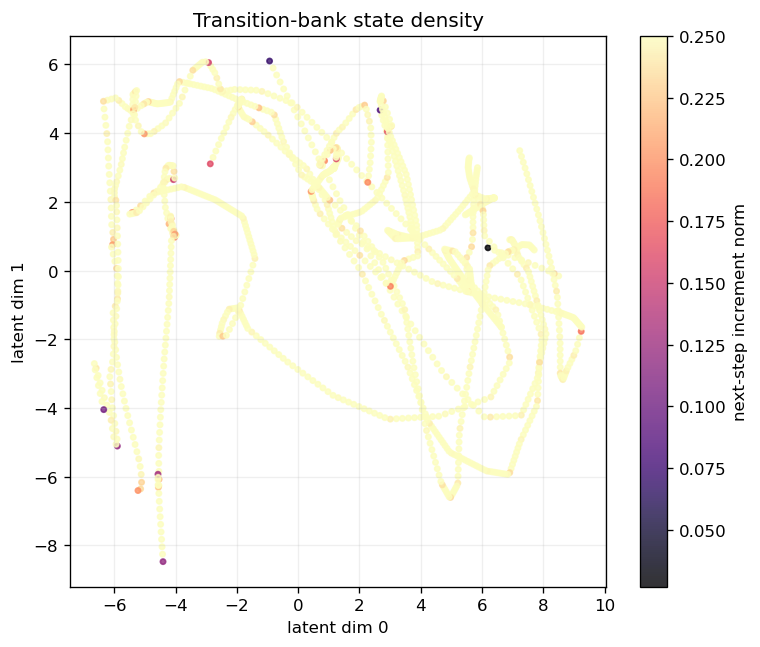

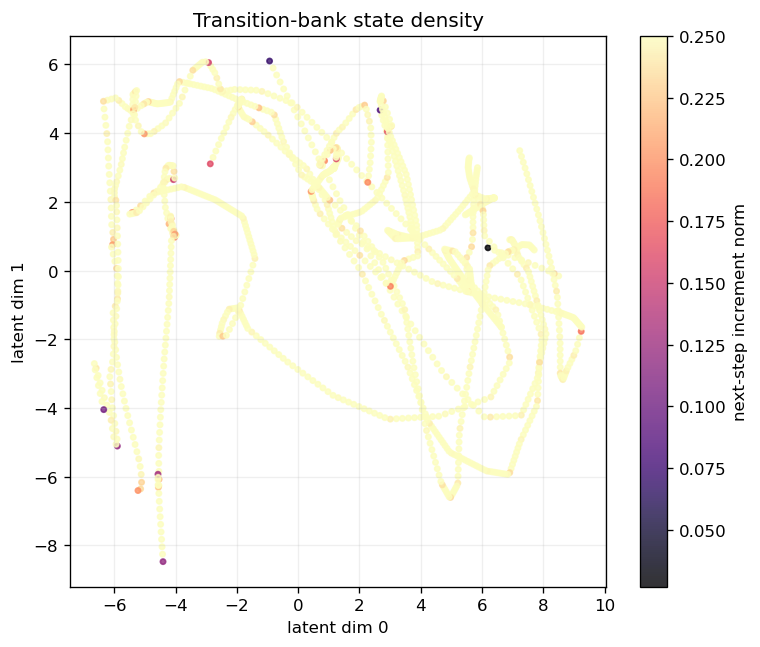

In [13]:
plot_bank_state_density(bank)


In [14]:
pd.DataFrame(
    {
        "segment_id": bank.segment_ids,
        "touches_interpolated_gap": bank.touches_interpolated_gap.astype(int),
    }
).groupby("segment_id").agg(["count", "sum"])


touches_interpolated_gap    
                              count sum
segment_id                             
0                              1509  38

## QC Questions

- Is `delta_s` too small, creating overly long resampled trajectories?
- Are windows being created near bad interpolation regions more often than expected?
- Does bank density reveal sparse regions where rollout support will later be weak?
